<a href="https://colab.research.google.com/github/tu25003-7491-cyber/EU_M_Math-Repository/blob/main/Chap05_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [88]:
import numpy as np
import numpy.random as random
import scipy as sp

import matplotlib.pyplot as plt
import matplotlib as mpl
%precision 3

'%.3f'

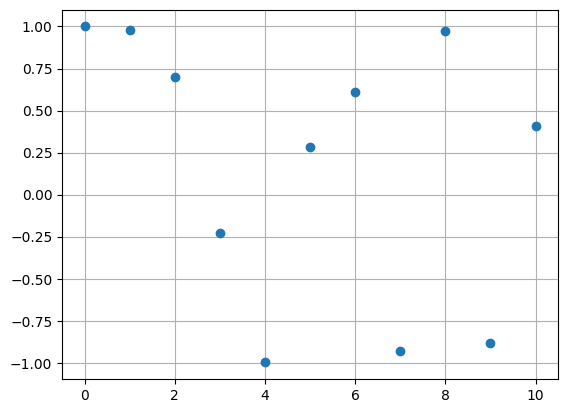

In [89]:
x = np.linspace(0, 10, num=11, endpoint=True)

y = np.cos(-x**2 / 5.0)
plt.plot(x, y, 'o')
plt.grid(True)
plt.show()

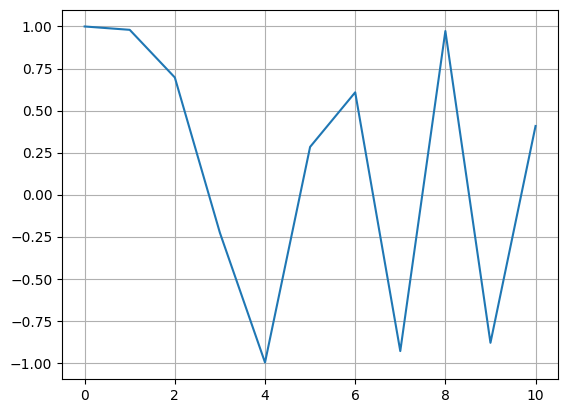

In [90]:
from scipy import interpolate

f = interpolate.interp1d(x, y, 'linear')

plt.plot(x, f(x), '-')
plt.grid(True)

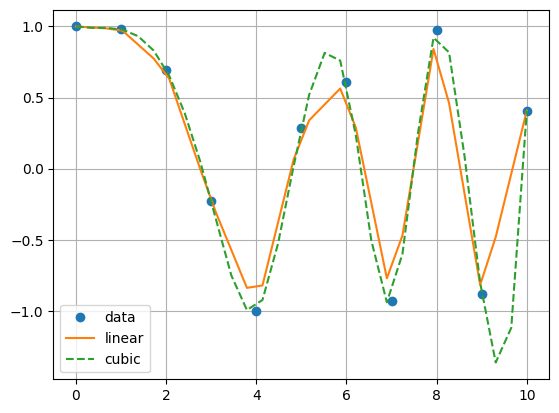

In [91]:
f2 = interpolate.interp1d(x, y, 'cubic')
xnew = np.linspace(0, 10, num=30, endpoint=True)

plt.plot(x, y, 'o', xnew, f(xnew), '-', xnew, f2(xnew), '--')
plt.legend(['data', 'linear', 'cubic'], loc='best')
plt.grid(True)

#練習問題5-10

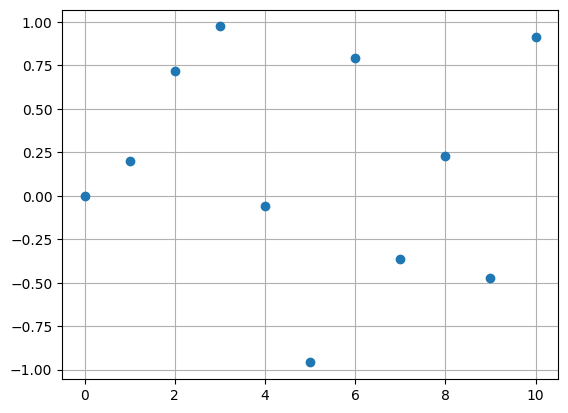

In [92]:
x = np.linspace(0, 10, num = 11, endpoint=True)
y = np.sin(x**2 / 5.0)
plt.plot(x, y, 'o')
plt.grid(True)

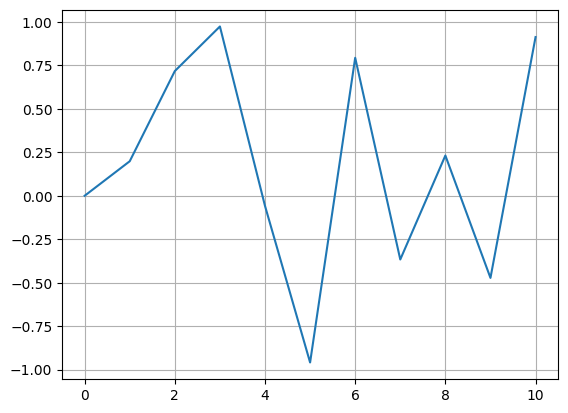

In [93]:
from scipy import interpolate

f = interpolate.interp1d(x, y, 'linear')

plt.plot(x, f(x), '-')
plt.grid(True)

#練習問題5-11

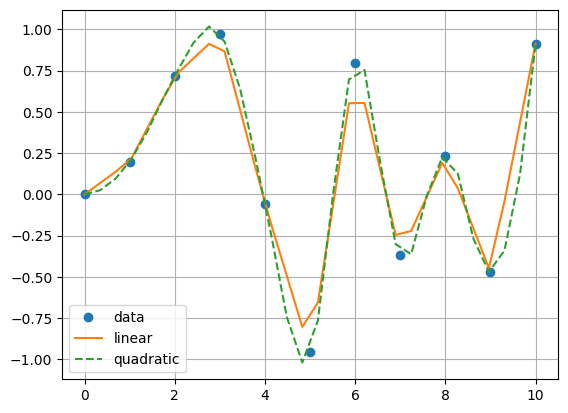

In [94]:
f2 = interpolate.interp1d(x, y, 'quadratic')
xnew = np.linspace(0, 10, num=30, endpoint=True)
plt.plot(x, y, 'o', xnew, f(xnew), '-', xnew, f2(xnew), '--')
plt.legend(['data', 'linear', 'quadratic'], loc='best')
plt.grid(True)

#練習問題5-12

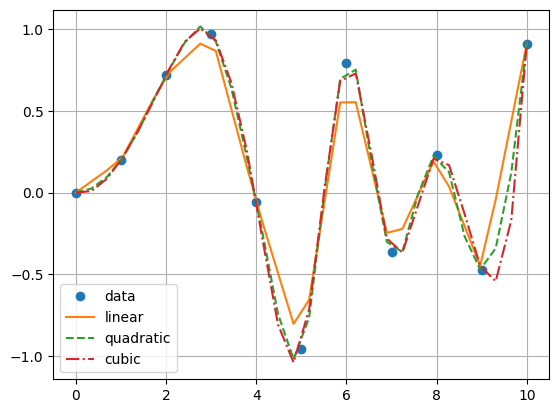

In [95]:

f3 = interpolate.interp1d(x, y, 'cubic')
xnew = np.linspace(0, 10, num=30, endpoint=True)

plt.plot(x, y, 'o', xnew, f(xnew), '-', xnew, f2(xnew), '--', xnew, f3(xnew), '-.')
plt.legend(['data', 'linear', 'quadratic', 'cubic'], loc='best')
plt.grid(True)
plt.show()

#5-3-3

In [96]:
from scipy import integrate
import math

def calcPi(x):
  return 4/(1+x**2)

print(integrate.quad(calcPi, 0, 1))
print(integrate.quad(lambda x: 4/(1+x**2), 0, 1))

(3.1415926535897936, 3.4878684980086326e-14)
(3.1415926535897936, 3.4878684980086326e-14)


In [97]:
from numpy import sin
integrate.quad(sin, 0, math.pi/1)

(2.000, 0.000)

In [98]:
def I(n):
  return integrate.dblquad(lambda t, x: np.exp(-x*t) / t**n, 0, np.inf, lambda x: 1, lambda x: np.inf)

print('n=1の時:', I(1))
print('n=2の時:', I(2))
print('n=3の時:', I(3))
print('n=4の時:', I(4))

n=1の時: (1.0000000000048965, 6.360750360104306e-08)
n=2の時: (0.4999999999985751, 1.3894083651858995e-08)
n=3の時: (0.33333333325010883, 1.3888461883425516e-08)
n=4の時: (0.2500000000043577, 1.2983033469368098e-08)


In [99]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def lorenz_func(v, t, p, r, b):
  return [-p * v[0] + p * v[1], -v[0]*v[2]+r*v[0]-v[1], v[0] * v[1] - b*v[2]]

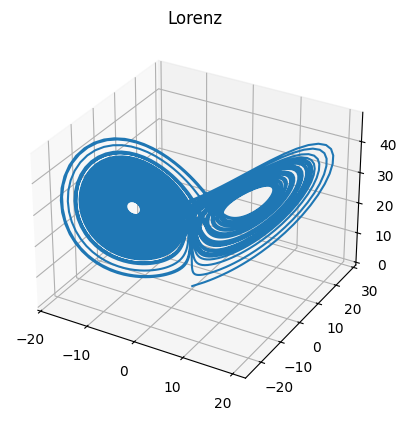

In [100]:
p = 10
r = 28
b = 8/3
v0 = [0.1, 0.1, 0.1]
t = np.arange(0, 100, 0.01)

v = odeint(lorenz_func, v0, t, args=(p, r, b))

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(v[:, 0], v[:, 1], v[:, 2])

plt.title('Lorenz')
plt.grid(True)
plt.show()

#練習問題5-15



In [101]:
def calcPi(x):
  return (x + 1)**2

print(integrate.quad(calcPi, 0, 2))
print(integrate.quad(lambda x: (x + 1)**2, 0, 2))

(8.666666666666668, 9.621932880084691e-14)
(8.666666666666668, 9.621932880084691e-14)


#練習問題5-16

In [102]:
from numpy import cos
integrate.quad(cos, 0, math.pi/1)

(0.000, 0.000)

#5-3-4


In [103]:
from scipy.optimize import fsolve
def f(x):
  y = 2 * x**2 + 2 * x - 10
  return y

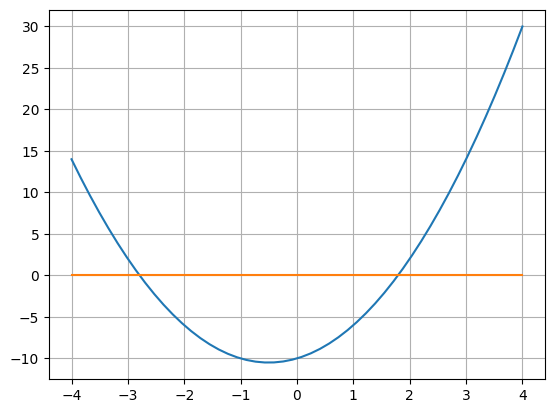

In [104]:
x = np.linspace(-4,4)
plt.plot(x, f(x))
plt.plot(x, np.zeros(len(x)))
plt.grid(True)

In [105]:
x = 2
x = fsolve(f,2)
print(x)

[1.791]


In [106]:
x = -3
x = fsolve(f,-3)
print(x)

[-2.791]


In [107]:
from scipy.optimize import minimize

In [108]:
def objective(x):
  x1 = x[0]
  x2 = x[1]
  x3 = x[2]
  x4 = x[3]
  return x1 * x4 * (x1 + x2 + x3) + x3

In [109]:
def constraint1(x):
  return x[0] * x[1] * x[2] * x[3] - 25.0

def constraint2(x):
  sum_sq = 40
  for i in range(4):
    sum_sq = sum_sq - x[i]**2
  return sum_sq

x0 = [1, 5, 5, 1]
print(objective(x0))

16


In [110]:
b = (1.0, 5.0)
bnds = (b, b, b, b)
con1 = {'type': 'ineq', 'fun': constraint1}
con2 = {'type': 'ineq', 'fun': constraint2}
cons = [con1,con2]

In [111]:
sol = minimize(objective, x0, method='SLSQP', bounds=bnds, constraints=cons)
print(sol)

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 17.01401724574784
           x: [ 1.000e+00  4.743e+00  3.821e+00  1.379e+00]
         nit: 5
         jac: [ 1.457e+01  1.379e+00  2.379e+00  9.564e+00]
        nfev: 25
        njev: 5
 multipliers: [ 5.523e-01  1.615e-01]


In [112]:
print('Y:',sol.fun)
print('X:',sol.x)

Y: 17.01401724574784
X: [1.    4.743 3.821 1.379]


#練習問題5-17

In [113]:
def f(x):
  y = 5 * x - 10
  return y
x = fsolve(f, 0)
print(x)

[2.]


#練習問題5-18

In [114]:
def f(x):
  y = x**3 - 2 * x**2 - 11 * x + 12
  return y
x = fsolve(f, 0)
print(x)

[1.]
